In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


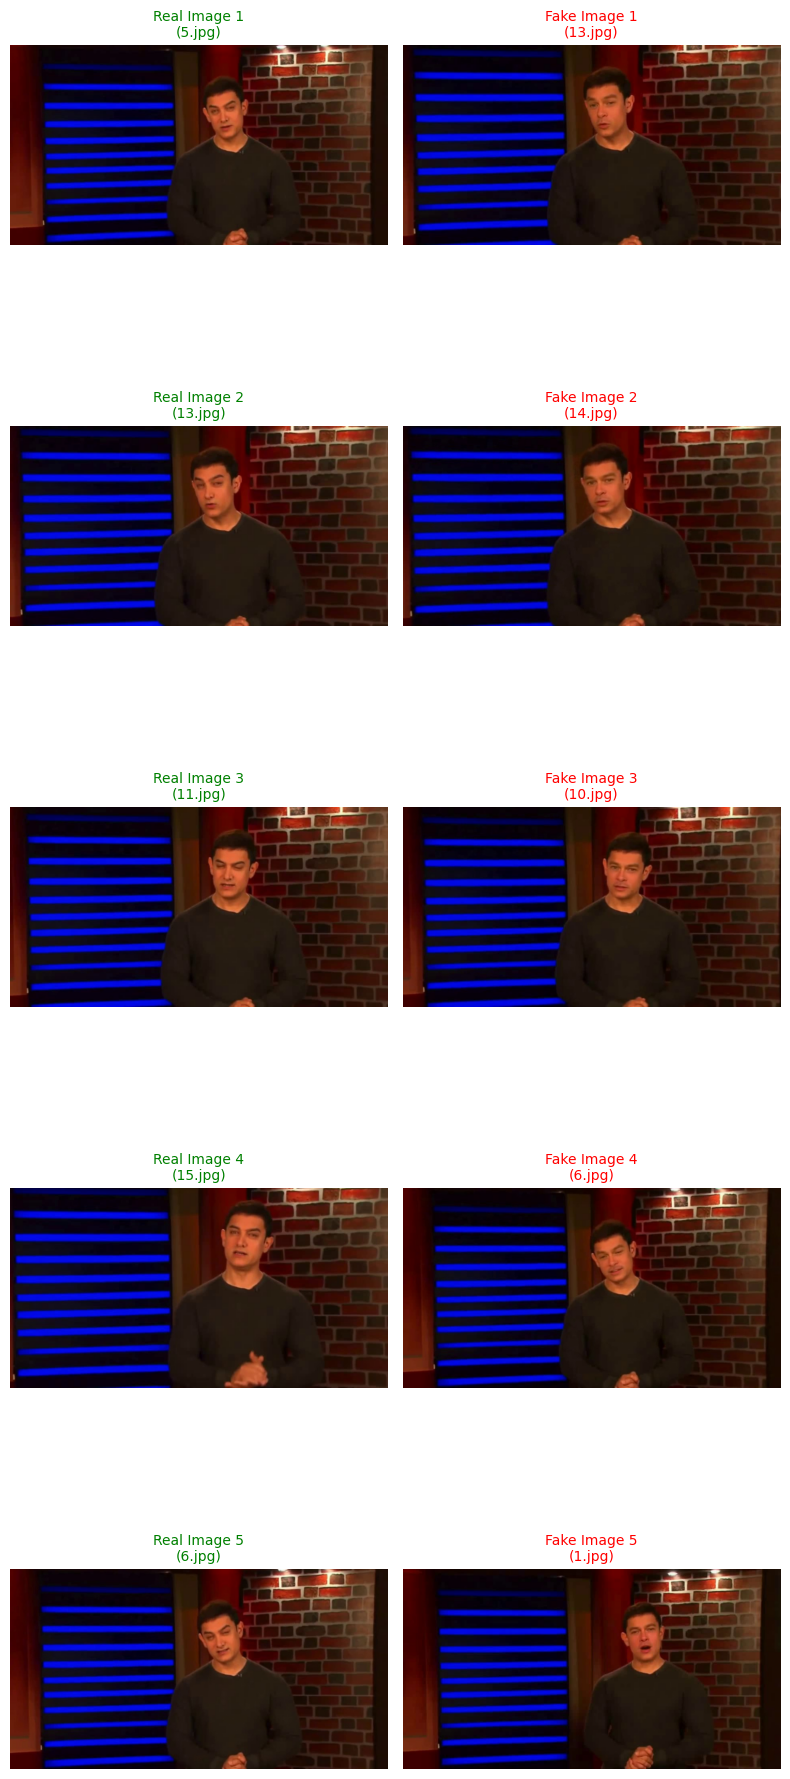

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 1. Define folder paths (update these to match your actual folder paths)
real_folder = '/content/drive/MyDrive/Real'
fake_folder = '/content/drive/MyDrive/Fake'

# 2. Supported image extensions
valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

# Helper function to get valid image file paths
def get_image_paths(folder_path):
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.lower().endswith(valid_extensions)
    ]

real_images = get_image_paths(real_folder)
fake_images = get_image_paths(fake_folder)

# 3. Choose how many pairs to display
num_pairs = 5  # Change this number as needed

# Ensure we don't try to sample more images than available
sample_count = min(num_pairs, len(real_images), len(fake_images))

# 4. Plot images side-by-side
fig, axes = plt.subplots(sample_count, 2, figsize=(8, 4 * sample_count))

# Handle single pair edge-case (matplotlib wraps axes differently for 1 row)
if sample_count == 1:
    axes = [axes]

for i in range(sample_count):
    # Load Real Image
    real_img = Image.open(real_images[i])
    axes[i][0].imshow(real_img)
    axes[i][0].set_title(f"Real Image {i+1}\n({os.path.basename(real_images[i])})", fontsize=10, color='green')
    axes[i][0].axis('off')

    # Load Fake Image
    fake_img = Image.open(fake_images[i])
    axes[i][1].imshow(fake_img)
    axes[i][1].set_title(f"Fake Image {i+1}\n({os.path.basename(fake_images[i])})", fontsize=10, color='red')
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
!pip install opencv-contrib-python


Loaded 36 Real image(s) and 36 Fake image(s).


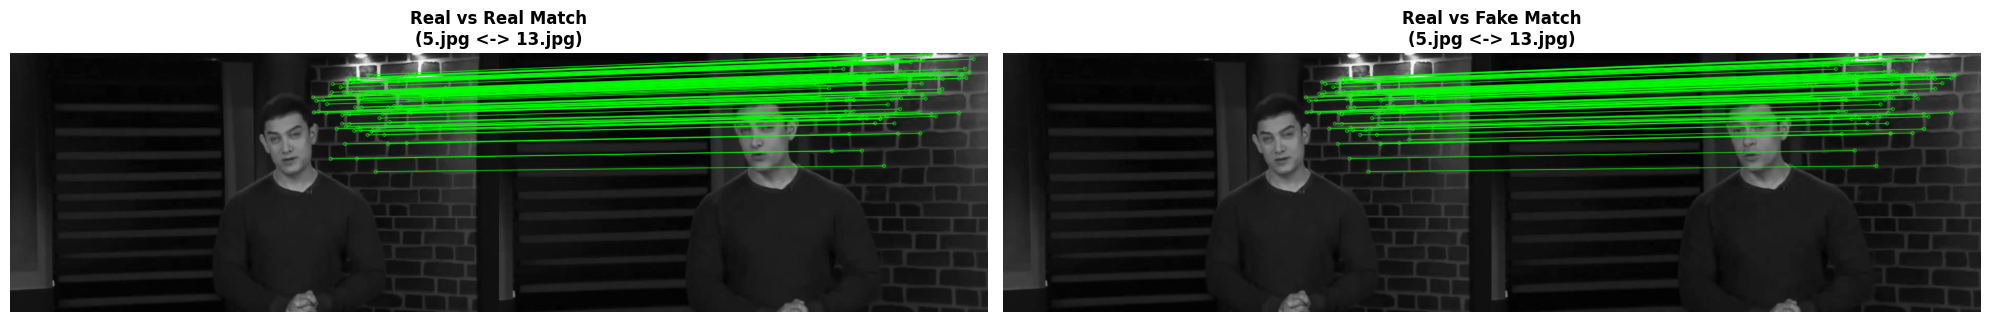

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# ==============================================================================
# 1. SET YOUR FOLDER PATHS HERE (Change these to your actual paths)
# ==============================================================================
real_output_folder = '/content/drive/MyDrive/Real'
fake_output_folder = '/content/drive/MyDrive/Fake'

# Supported image file extensions
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

# Helper function to get valid image files from a directory
def get_image_paths(folder_path):
    if not os.path.exists(folder_path):
        print(f"Error: Folder path does not exist: '{folder_path}'")
        return []
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

# Define function to apply RANSAC on a pair of images
def ransac_feature_matching(img1_path, img2_path, title="RANSAC Feature Matches", output_path=None, ax=None):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error: Could not load images from {img1_path} or {img2_path}")
        return None

    # Use SIFT for feature detection
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print(f"Warning: No feature descriptors found in one of the images.")
        return None

    # Use FLANN-based matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    # Apply Lowe's ratio test
    good_matches = []
    for match in matches:
        if len(match) == 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    if len(good_matches) > 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # RANSAC to filter outliers
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist() if mask is not None else None
    else:
        matchesMask = None

    # Draw matches
    draw_params = dict(
        matchColor=(0, 255, 0),      # Inliers rendered in green
        singlePointColor=None,
        matchesMask=matchesMask,     # Show only inlier matches
        flags=2
    )

    result_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, **draw_params)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # Save or display the result
    if output_path:
        cv2.imwrite(output_path, result_img)

    if ax is not None:
        ax.imshow(result_img_rgb)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    return result_img_rgb


# ==============================================================================
# 2. RUN FEATURE MATCHING PROCESS
# ==============================================================================
real_frame_paths = get_image_paths(real_output_folder)
fake_frame_paths = get_image_paths(fake_output_folder)

print(f"Loaded {len(real_frame_paths)} Real image(s) and {len(fake_frame_paths)} Fake image(s).")

if len(real_frame_paths) >= 1 and len(fake_frame_paths) >= 1:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Match 1: Real vs Real (Requires at least 2 real images)
    if len(real_frame_paths) >= 2:
        ransac_feature_matching(
            real_frame_paths[0],
            real_frame_paths[1],
            title=f"Real vs Real Match\n({os.path.basename(real_frame_paths[0])} <-> {os.path.basename(real_frame_paths[1])})",
            ax=axes[0]
        )
    else:
        axes[0].text(0.5, 0.5, 'Need at least 2 real images for Real vs Real matching', ha='center', va='center')
        axes[0].axis('off')

    # Match 2: Real vs Fake
    ransac_feature_matching(
        real_frame_paths[0],
        fake_frame_paths[0],
        title=f"Real vs Fake Match\n({os.path.basename(real_frame_paths[0])} <-> {os.path.basename(fake_frame_paths[0])})",
        output_path="/content/ransac_real_vs_fake.jpg",
        ax=axes[1]
    )

    plt.tight_layout()
    plt.show()
else:
    print("Error: Both real and fake folders must contain at least one valid image.")

Loaded 36 Real image(s) and 36 Fake image(s).



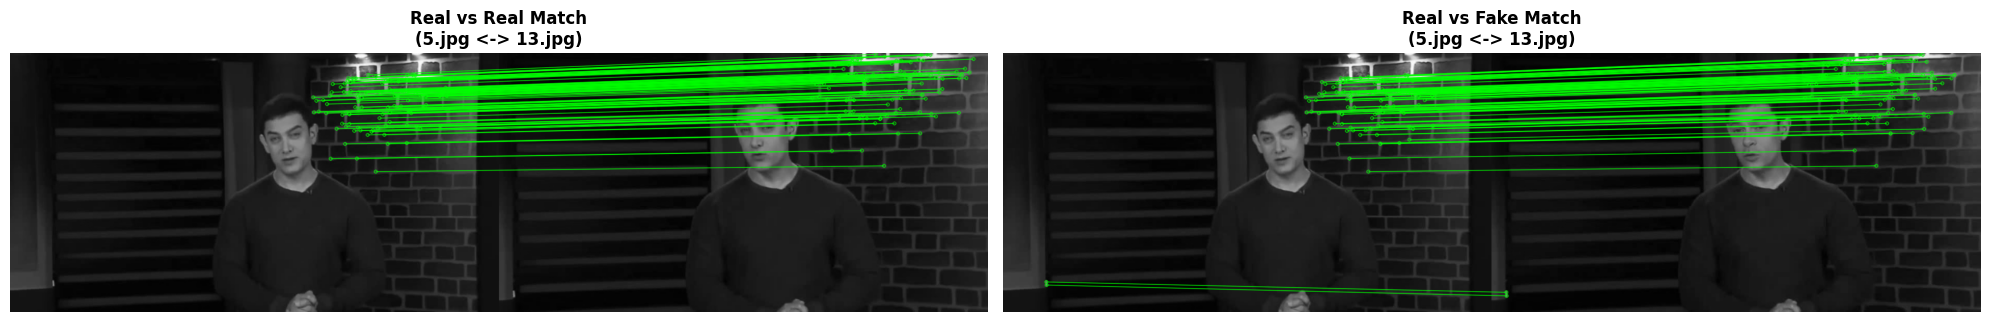


EXTRACTED FEATURE MATCHING METRICS TABLE
Comparison Type Image 1 Name Image 2 Name  Keypoints (Img 1)  Keypoints (Img 2)  Total Matches  Good Matches (Ratio Test)  Inlier Matches (RANSAC)  Inlier Ratio (%) Homography Found
   Real vs Real        5.jpg       13.jpg                357                265            357                        145                      104             71.72              Yes
   Real vs Fake        5.jpg       13.jpg                357                262            357                        127                       99             77.95              Yes


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. SET YOUR FOLDER PATHS HERE (Change these to your actual paths)
# ==============================================================================
real_output_folder = '/content/drive/MyDrive/Real'
fake_output_folder = '/content/drive/MyDrive/Fake'

# Supported image file extensions
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')

# Helper function to get valid image files from a directory
def get_image_paths(folder_path):
    if not os.path.exists(folder_path):
        print(f"Error: Folder path does not exist: '{folder_path}'")
        return []
    return [
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.lower().endswith(VALID_EXTENSIONS)
    ]

# Define function to apply RANSAC on a pair of images and return feature stats
def ransac_feature_matching(img1_path, img2_path, comparison_type="Real vs Real", title="RANSAC Feature Matches", output_path=None, ax=None):
    img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error: Could not load images from {img1_path} or {img2_path}")
        return None, None

    # Use SIFT for feature detection
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print(f"Warning: No feature descriptors found in one of the images.")
        return None, None

    # Use FLANN-based matcher
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    # Apply Lowe's ratio test
    good_matches = []
    for match in matches:
        if len(match) == 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    inlier_count = 0
    homography_matrix = None
    if len(good_matches) > 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        # RANSAC to filter outliers
        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        homography_matrix = H
        matchesMask = mask.ravel().tolist() if mask is not None else None
        inlier_count = int(np.sum(mask)) if mask is not None else 0
    else:
        matchesMask = None

    # Draw matches
    draw_params = dict(
        matchColor=(0, 255, 0),      # Inliers rendered in green
        singlePointColor=None,
        matchesMask=matchesMask,     # Show only inlier matches
        flags=2
    )

    result_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, **draw_params)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # Save or display the result
    if output_path:
        cv2.imwrite(output_path, result_img)

    if ax is not None:
        ax.imshow(result_img_rgb)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    # Compile quantitative features/metrics for the table
    metrics = {
        "Comparison Type": comparison_type,
        "Image 1 Name": os.path.basename(img1_path),
        "Image 2 Name": os.path.basename(img2_path),
        "Keypoints (Img 1)": len(kp1),
        "Keypoints (Img 2)": len(kp2),
        "Total Matches": len(matches),
        "Good Matches (Ratio Test)": len(good_matches),
        "Inlier Matches (RANSAC)": inlier_count,
        "Inlier Ratio (%)": round((inlier_count / len(good_matches) * 100) if len(good_matches) > 0 else 0, 2),
        "Homography Found": "Yes" if homography_matrix is not None else "No"
    }

    return result_img_rgb, metrics


# ==============================================================================
# 2. RUN FEATURE MATCHING PROCESS & GENERATE TABLE
# ==============================================================================
real_frame_paths = get_image_paths(real_output_folder)
fake_frame_paths = get_image_paths(fake_output_folder)

print(f"Loaded {len(real_frame_paths)} Real image(s) and {len(fake_frame_paths)} Fake image(s).\n")

table_data = []

if len(real_frame_paths) >= 1 and len(fake_frame_paths) >= 1:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Match 1: Real vs Real (Requires at least 2 real images)
    if len(real_frame_paths) >= 2:
        _, metrics_rr = ransac_feature_matching(
            real_frame_paths[0],
            real_frame_paths[1],
            comparison_type="Real vs Real",
            title=f"Real vs Real Match\n({os.path.basename(real_frame_paths[0])} <-> {os.path.basename(real_frame_paths[1])})",
            ax=axes[0]
        )
        if metrics_rr:
            table_data.append(metrics_rr)
    else:
        axes[0].text(0.5, 0.5, 'Need at least 2 real images for Real vs Real matching', ha='center', va='center')
        axes[0].axis('off')

    # Match 2: Real vs Fake
    _, metrics_rf = ransac_feature_matching(
        real_frame_paths[0],
        fake_frame_paths[0],
        comparison_type="Real vs Fake",
        title=f"Real vs Fake Match\n({os.path.basename(real_frame_paths[0])} <-> {os.path.basename(fake_frame_paths[0])})",
        output_path="/content/ransac_real_vs_fake.jpg",
        ax=axes[1]
    )
    if metrics_rf:
        table_data.append(metrics_rf)

    plt.tight_layout()
    plt.show()

    # Print Feature Extraction Table
    if table_data:
        df_features = pd.DataFrame(table_data)
        print("\n" + "="*80)
        print("EXTRACTED FEATURE MATCHING METRICS TABLE")
        print("="*80)
        display(df_features) if 'display' in globals() else print(df_features.to_string(index=False))
else:
    print("Error: Both real and fake folders must contain at least one valid image.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Comparing Real Image: 1.jpg
With Fake Image: 1.jpg



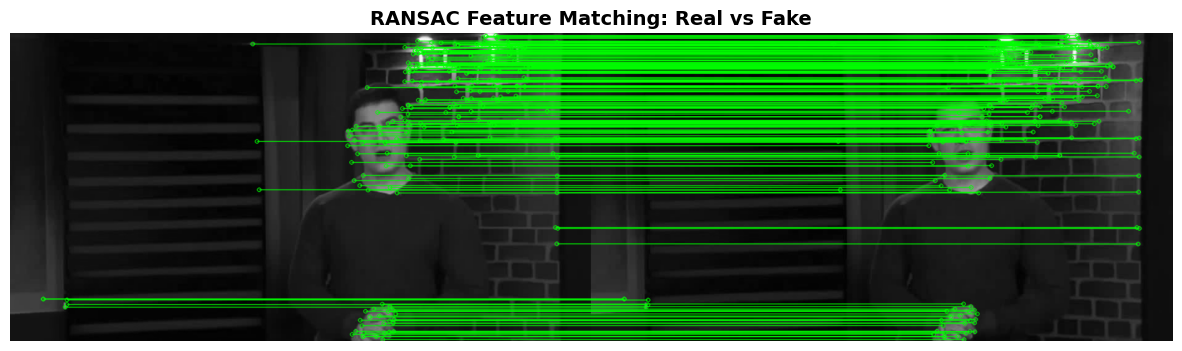

Saved matched result to /content/ransac_real_vs_fake_custom.jpg

EXTRACTED FEATURE MATCHING METRICS TABLE
Comparison Type Real Image Name Fake Image Name  Keypoints (Real)  Keypoints (Fake)  Total Matches  Good Matches (Ratio Test)  Inlier Matches (RANSAC)  Inlier Ratio (%) Homography Found
   Real vs Fake           1.jpg           1.jpg               328               330            328                        238                      230             96.64              Yes


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. MOUNT GOOGLE DRIVE (Run this to access your Drive)
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# 2. SET THE FULL PATHS TO YOUR SPECIFIC REAL AND FAKE IMAGES IN DRIVE
# ==============================================================================
# Example:
# real_image_path = '/content/drive/MyDrive/dataset/real/image_001.jpg'
# fake_image_path = '/content/drive/MyDrive/dataset/fake/image_001.jpg'

real_image_path = '/content/drive/MyDrive/Real/1.jpg'
fake_image_path = '/content/drive/MyDrive/Fake/1.jpg'


# Function to apply RANSAC feature matching between two specific images
def ransac_feature_matching(image1_path, image2_path, comparison_type="Real vs Fake", title="RANSAC Feature Matches", output_path=None):
    # Load images in grayscale
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    if img1 is None or img2 is None:
        print(f"Error: Could not load images from '{image1_path}' or '{image2_path}'. Please check your file paths.")
        return None, None

    # Feature detector
    sift = cv2.SIFT_create()

    # Compute keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print("Warning: No feature descriptors found in one of the images.")
        return None, None

    # FLANN matcher setup
    index_params = dict(algorithm=1, trees=5)  # Algorithm 1 = KDTree for SIFT
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    # Match descriptors using KNN
    matches = flann.knnMatch(des1, des2, k=2)

    # Apply Lowe's ratio test
    good_matches = []
    for match in matches:
        if len(match) == 2:
            m, n = match
            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    inlier_count = 0
    homography_matrix = None

    # Apply RANSAC to filter matches
    if len(good_matches) > 4:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
        homography_matrix = H
        matchesMask = mask.ravel().tolist() if mask is not None else None
        inlier_count = int(np.sum(mask)) if mask is not None else 0
    else:
        matchesMask = None

    # Draw the matches
    draw_params = dict(
        matchColor=(0, 255, 0),
        singlePointColor=None,
        matchesMask=matchesMask,
        flags=2
    )

    result_img = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, **draw_params)
    result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    # Display the result using Matplotlib
    plt.figure(figsize=(15, 8))
    plt.imshow(result_img_rgb)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis("off")
    plt.show()

    # Save output if requested
    if output_path:
        cv2.imwrite(output_path, result_img)
        print(f"Saved matched result to {output_path}")

    # Compile quantitative features/metrics for the table
    metrics = {
        "Comparison Type": comparison_type,
        "Real Image Name": os.path.basename(image1_path),
        "Fake Image Name": os.path.basename(image2_path),
        "Keypoints (Real)": len(kp1),
        "Keypoints (Fake)": len(kp2),
        "Total Matches": len(matches),
        "Good Matches (Ratio Test)": len(good_matches),
        "Inlier Matches (RANSAC)": inlier_count,
        "Inlier Ratio (%)": round((inlier_count / len(good_matches) * 100) if len(good_matches) > 0 else 0, 2),
        "Homography Found": "Yes" if homography_matrix is not None else "No"
    }

    return result_img_rgb, metrics


# ==============================================================================
# 3. EXECUTE MATCHING AND PRINT METRICS TABLE
# ==============================================================================
print(f"Comparing Real Image: {os.path.basename(real_image_path)}")
print(f"With Fake Image: {os.path.basename(fake_image_path)}\n")

_, metrics = ransac_feature_matching(
    real_image_path,
    fake_image_path,
    comparison_type="Real vs Fake",
    title=f"RANSAC Feature Matching: Real vs Fake",
    output_path="/content/ransac_real_vs_fake_custom.jpg"
)

if metrics:
    df_features = pd.DataFrame([metrics])
    print("\n" + "="*80)
    print("EXTRACTED FEATURE MATCHING METRICS TABLE")
    print("="*80)
    display(df_features) if 'display' in globals() else print(df_features.to_string(index=False))


In [ ]:
# Clone YOLOv5 repo and install requirements
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt


Cloning into 'yolov5'...
remote: Enumerating objects: 18689, done.
remote: Counting objects: 100% (286/286), done.
remote: Compressing objects: 100% (164/164), done.
remote: Total 18689 (delta 234), reused 122 (delta 122), pack-reused 18403 (from 3)
Receiving objects: 100% (18689/18689), 17.68 MiB | 19.40 MiB/s, done.
Resolving deltas: 100% (12729/12729), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


In [ ]:
import os
import zipfile
import shutil
import cv2
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torchvision import transforms

# ==============================================================================
# 1. KAGGLE API AUTHENTICATION & IMAGE DATASET DOWNLOAD
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/root/.kaggle', exist_ok=True)
drive_kaggle_path = '/content/kaggle.json'

if os.path.exists('/content/kaggle.json'):
    !cp /content/kaggle.json /root/.kaggle/
elif os.path.exists(drive_kaggle_path):
    !cp {drive_kaggle_path} /root/.kaggle/
else:
    raise FileNotFoundError("Please place your 'kaggle.json' file in your Google Drive root directory.")

!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

DOWNLOAD_DIR = '/content/celeb_df_image_raw'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Downloading Celeb-DF-v2 Image Dataset from Kaggle...")
!kaggle datasets download -d pranabr0y/celebdf-v2image-dataset --path {DOWNLOAD_DIR}

zip_path = os.path.join(DOWNLOAD_DIR, 'celebdf-v2image-dataset.zip')
extracted_path = os.path.join(DOWNLOAD_DIR, 'extracted')
os.makedirs(extracted_path, exist_ok=True)

if os.path.exists(zip_path):
    print("Extracting image dataset zip file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)
else:
    # Handle case if kaggle downloads folder name directly or different zip name
    zip_files = [f for f in os.listdir(DOWNLOAD_DIR) if f.endswith('.zip')]
    if zip_files:
        with zipfile.ZipFile(os.path.join(DOWNLOAD_DIR, zip_files[0]), 'r') as zip_ref:
            zip_ref.extractall(extracted_path)
    else:
        raise FileNotFoundError(f"Could not find zip archive in {DOWNLOAD_DIR}")

print("Dataset extraction complete.")

# ==============================================================================
# 2. LOCATE & ORGANIZE IMAGES INTO YOLOv5 CLASSIFICATION STRUCTURE
# ==============================================================================

# Locate raw real and fake image directories inside extracted path
source_real_dir, source_fake_dir = None, None
for root, dirs, files in os.walk(extracted_path):
    for d in dirs:
        if d.lower() == 'real':
            source_real_dir = os.path.join(root, d)
        elif d.lower() == 'fake':
            source_fake_dir = os.path.join(root, d)

if not source_real_dir or not source_fake_dir:
    raise FileNotFoundError("Could not automatically locate 'real' and 'fake' subfolders in the extracted dataset.")

def get_images(folder):
    return [os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

real_images = get_images(source_real_dir)
fake_images = get_images(source_fake_dir)

print(f"Found {len(real_images)} Real images and {len(fake_images)} Fake images.")

# Setup YOLOv5 classification directory layout
# Note: YOLOv5-cls automatically maps classes alphabetically ('fake' -> index 0, 'real' -> index 1)
YOLO_CLASSIFY_DIR = '/content/yolo_celeb_classify'
for split in ['train', 'val', 'test']:
    for cat in ['fake', 'real']:
        os.makedirs(os.path.join(YOLO_CLASSIFY_DIR, split, cat), exist_ok=True)

def partition_and_copy(image_paths, category):
    if not image_paths:
        return
    train_files, temp_files = train_test_split(image_paths, test_size=0.30, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=2/3, random_state=42)

    splits = {'train': train_files, 'val': val_files, 'test': test_files}
    for split_name, files in splits.items():
        dest_dir = os.path.join(YOLO_CLASSIFY_DIR, split_name, category)
        for src_path in files:
            shutil.copyfile(src_path, os.path.join(dest_dir, os.path.basename(src_path)))

print("Partitioning dataset into Train (70%), Val (10%), and Test (20%)...")
partition_and_copy(real_images, 'real')
partition_and_copy(fake_images, 'fake')
print("Dataset successfully structured for YOLOv5 classification.")

# ==============================================================================
# 3. CLONE YOLOV5 & RUN CLASSIFICATION TRAINING
# ==============================================================================

if not os.path.exists('/content/yolov5'):
    !git clone https://github.com/ultralytics/yolov5
%cd /content/yolov5
!pip install -qr requirements.txt

EPOCHS = 10          # Adjust epochs based on your compute availability
BATCH_SIZE = 64     # Increase batch size if running on a high-end GPU (like T4/L4)
IMG_SIZE = 224

print(f"\nStarting YOLOv5 Image Classification training for {EPOCHS} epochs...")
!python classify/train.py \
    --model yolov5s-cls.pt \
    --data {YOLO_CLASSIFY_DIR} \
    --epochs {EPOCHS} \
    --img {IMG_SIZE} \
    --batch {BATCH_SIZE} \
    --name celeb_detector_cls \
    --cache \
    --workers 2



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/pranabr0y/celebdf-v2image-dataset
License(s): other
celebdf-v2image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting image dataset zip file...
Dataset extraction complete.
Found 5036 Real images and 5067 Fake images.
Partitioning dataset into Train (70%), Val (10%), and Test (20%)...
Dataset successfully structured for YOLOv5 classification.
/content/yolov5

Starting YOLOv5 Image Classification training for 10 epochs...
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/pranabr0y/celebdf-v2image-dataset
License(s): other
celebdf-v2image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting dataset...
Dataset extraction completed.

Real folder:
/content/celeb_df_image_raw/extracted/Celeb_V2/Test/real

Fake folder:
/content/celeb_df_image_raw/extracted/Celeb_V2/Test/fake

DATASET INFORMATION
Real images : 5036
Fake images : 5067
Total images: 10103

Copying Real images...
Copying Fake images...

Dataset organization completed.

DATASET SPLIT
Training:
  Real: 3525
  Fake: 3546

Validation:
  Real: 503
  Fake: 507

Testing:
  Real: 1008
  Fake: 1014

DEVICE
Using: cuda
GPU: Tesla T4

Class mapping:
{'fake': 0, 'real': 1}

Loading pretrained ResNet-50...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /roo

100%|██████████| 97.8M/97.8M [00:00<00:00, 159MB/s]



ResNet-50 model loaded successfully.

STARTING RESNET-50 TRAINING
Epoch [1/10] | Train Loss: 0.3766 | Train Acc: 81.88% | Val Loss: 0.3102 | Val Acc: 87.33% | Time: 71.2s <-- BEST MODEL
Epoch [2/10] | Train Loss: 0.1714 | Train Acc: 93.59% | Val Loss: 0.1330 | Val Acc: 94.65% | Time: 75.0s <-- BEST MODEL
Epoch [3/10] | Train Loss: 0.1083 | Train Acc: 95.96% | Val Loss: 0.0951 | Val Acc: 95.84% | Time: 80.9s <-- BEST MODEL
Epoch [4/10] | Train Loss: 0.0864 | Train Acc: 96.69% | Val Loss: 0.1245 | Val Acc: 95.05% | Time: 81.5s
Epoch [5/10] | Train Loss: 0.0707 | Train Acc: 97.30% | Val Loss: 0.2628 | Val Acc: 89.80% | Time: 80.3s
Epoch [6/10] | Train Loss: 0.0585 | Train Acc: 98.03% | Val Loss: 0.3668 | Val Acc: 89.11% | Time: 81.1s
Epoch [7/10] | Train Loss: 0.0392 | Train Acc: 98.67% | Val Loss: 0.0727 | Val Acc: 97.13% | Time: 80.8s <-- BEST MODEL
Epoch [8/10] | Train Loss: 0.0189 | Train Acc: 99.38% | Val Loss: 0.0625 | Val Acc: 97.82% | Time: 81.6s <-- BEST MODEL
Epoch [9/10] | Tra

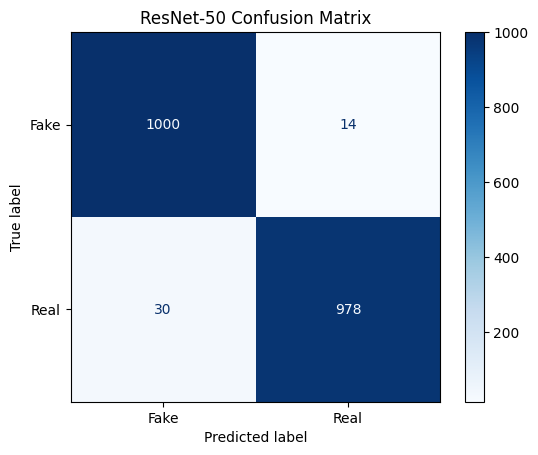

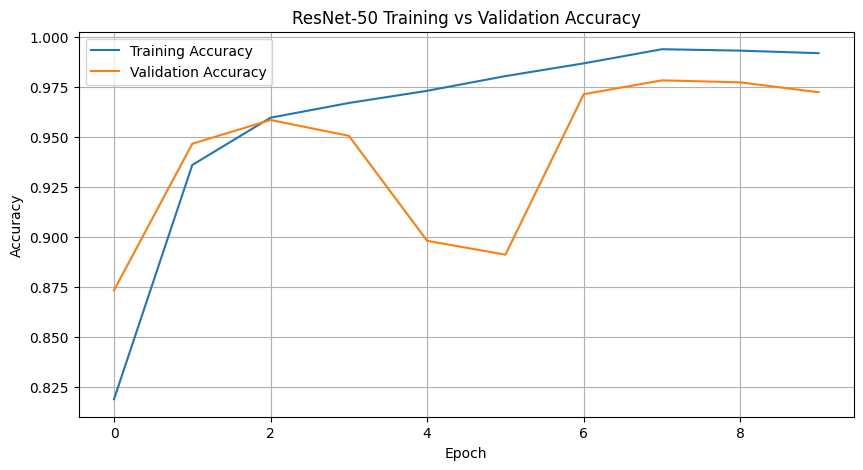

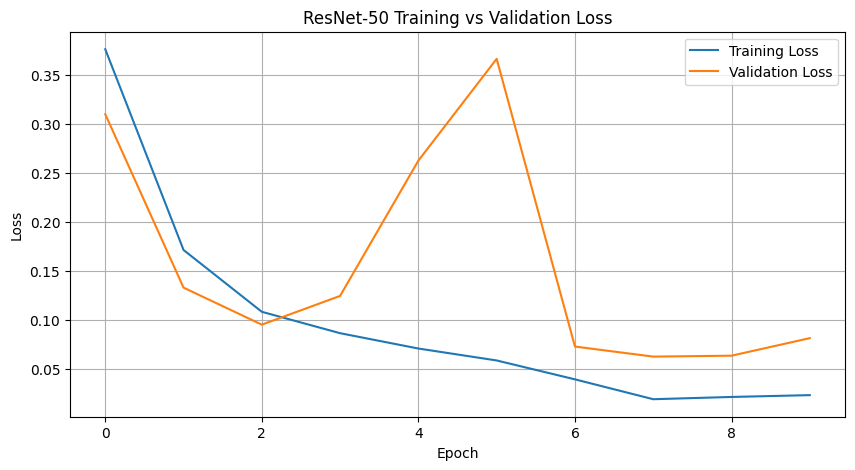


CELEB-DF RESNET-50 PERFORMANCE TABLE


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,ResNet-50,97.82,97.84,97.82,97.82



Performance table saved to:
/content/resnet50_performance.csv

Best model saved as:
/content/resnet50_celeb_best.pth

Final model saved as:
/content/resnet50_celeb_final.pth

RESNET-50 CLASSIFICATION COMPLETED


In [ ]:
# ==============================================================================
# RESNET-50 FOR CELEB-DF REAL vs FAKE IMAGE CLASSIFICATION
# ==============================================================================

# ==============================================================================
# 1. IMPORT LIBRARIES
# ==============================================================================

import os
import zipfile
import shutil
import random
import copy
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ==============================================================================
# 2. GOOGLE DRIVE
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

# ==============================================================================
# 3. KAGGLE AUTHENTICATION
# ==============================================================================

os.makedirs('/root/.kaggle', exist_ok=True)

drive_kaggle_path = '/content/kaggle.json'
content_kaggle_path = '/content/kaggle.json'

if os.path.exists(content_kaggle_path):
    shutil.copy(content_kaggle_path, '/root/.kaggle/kaggle.json')

elif os.path.exists(drive_kaggle_path):
    shutil.copy(drive_kaggle_path, '/root/.kaggle/kaggle.json')

else:
    raise FileNotFoundError(
        "Please place kaggle.json in /content/ or /content/drive/MyDrive/"
    )

os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle

# ==============================================================================
# 4. DOWNLOAD DATASET
# ==============================================================================

DOWNLOAD_DIR = '/content/celeb_df_image_raw'

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Downloading Celeb-DF-v2 Image Dataset...")

!kaggle datasets download \
    -d pranabr0y/celebdf-v2image-dataset \
    --path {DOWNLOAD_DIR}

# ==============================================================================
# 5. EXTRACT DATASET
# ==============================================================================

EXTRACTED_DIR = os.path.join(DOWNLOAD_DIR, 'extracted')

os.makedirs(EXTRACTED_DIR, exist_ok=True)

zip_files = [
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.lower().endswith('.zip')
]

if not zip_files:
    raise FileNotFoundError(
        f"No ZIP file found in {DOWNLOAD_DIR}"
    )

zip_path = os.path.join(DOWNLOAD_DIR, zip_files[0])

print("Extracting dataset...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(EXTRACTED_DIR)

print("Dataset extraction completed.")

# ==============================================================================
# 6. FIND REAL AND FAKE FOLDERS
# ==============================================================================

source_real_dir = None
source_fake_dir = None

for root, dirs, files in os.walk(EXTRACTED_DIR):

    for d in dirs:

        if d.lower() == 'real':
            source_real_dir = os.path.join(root, d)

        elif d.lower() == 'fake':
            source_fake_dir = os.path.join(root, d)

if source_real_dir is None:
    raise FileNotFoundError(
        "Could not find the 'real' folder."
    )

if source_fake_dir is None:
    raise FileNotFoundError(
        "Could not find the 'fake' folder."
    )

print("\nReal folder:")
print(source_real_dir)

print("\nFake folder:")
print(source_fake_dir)

# ==============================================================================
# 7. GET IMAGE FILES
# ==============================================================================

def get_images(folder):

    image_extensions = (
        '.jpg',
        '.jpeg',
        '.png',
        '.bmp',
        '.webp'
    )

    images = []

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.lower().endswith(image_extensions):

                images.append(
                    os.path.join(root, file)
                )

    return images


real_images = get_images(source_real_dir)
fake_images = get_images(source_fake_dir)

print("\n============================================================")
print("DATASET INFORMATION")
print("============================================================")

print("Real images :", len(real_images))
print("Fake images :", len(fake_images))
print("Total images:", len(real_images) + len(fake_images))

# ==============================================================================
# 8. CREATE TRAIN / VALIDATION / TEST DATASET
# ==============================================================================

BASE_DIR = '/content/resnet50_celeb_dataset'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    os.makedirs(
        os.path.join(split_dir, 'fake'),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(split_dir, 'real'),
        exist_ok=True
    )

# ==============================================================================
# 9. SPLIT DATA
# ==============================================================================

def split_images(image_list):

    # 70% training
    # 30% temporary

    train_files, temp_files = train_test_split(
        image_list,
        test_size=0.30,
        random_state=42
    )

    # Remaining 30%
    # 1/3 = validation = 10%
    # 2/3 = test = 20%

    val_files, test_files = train_test_split(
        temp_files,
        test_size=2/3,
        random_state=42
    )

    return train_files, val_files, test_files


real_train, real_val, real_test = split_images(real_images)

fake_train, fake_val, fake_test = split_images(fake_images)

# ==============================================================================
# 10. COPY FILES
# ==============================================================================

def copy_images(files, destination):

    for i, src in enumerate(files):

        # Create unique filename
        filename = f"{i}_{os.path.basename(src)}"

        destination_path = os.path.join(
            destination,
            filename
        )

        shutil.copy2(
            src,
            destination_path
        )


print("\nCopying Real images...")

copy_images(
    real_train,
    os.path.join(TRAIN_DIR, 'real')
)

copy_images(
    real_val,
    os.path.join(VAL_DIR, 'real')
)

copy_images(
    real_test,
    os.path.join(TEST_DIR, 'real')
)

print("Copying Fake images...")

copy_images(
    fake_train,
    os.path.join(TRAIN_DIR, 'fake')
)

copy_images(
    fake_val,
    os.path.join(VAL_DIR, 'fake')
)

copy_images(
    fake_test,
    os.path.join(TEST_DIR, 'fake')
)

print("\nDataset organization completed.")

# ==============================================================================
# 11. SHOW DATASET DISTRIBUTION
# ==============================================================================

print("\n============================================================")
print("DATASET SPLIT")
print("============================================================")

print("Training:")
print("  Real:", len(real_train))
print("  Fake:", len(fake_train))

print("\nValidation:")
print("  Real:", len(real_val))
print("  Fake:", len(fake_val))

print("\nTesting:")
print("  Real:", len(real_test))
print("  Fake:", len(fake_test))

# ==============================================================================
# 12. DEVICE
# ==============================================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("\n============================================================")
print("DEVICE")
print("============================================================")

print("Using:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ==============================================================================
# 13. IMAGE TRANSFORMATIONS
# ==============================================================================

IMG_SIZE = 224

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        10
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==============================================================================
# 14. LOAD DATASETS
# ==============================================================================

train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

# Expected:
# fake = 0
# real = 1

# ==============================================================================
# 15. DATA LOADERS
# ==============================================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ==============================================================================
# 16. LOAD PRETRAINED RESNET-50
# ==============================================================================

print("\nLoading pretrained ResNet-50...")

weights = ResNet50_Weights.DEFAULT

model = models.resnet50(
    weights=weights
)

# ==============================================================================
# 17. REPLACE FINAL CLASSIFICATION LAYER
# ==============================================================================

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

model = model.to(device)

print("\nResNet-50 model loaded successfully.")

# ==============================================================================
# 18. LOSS FUNCTION
# ==============================================================================

criterion = nn.CrossEntropyLoss()

# ==============================================================================
# 19. OPTIMIZER
# ==============================================================================

LEARNING_RATE = 0.0001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# ==============================================================================
# 20. LEARNING RATE SCHEDULER
# ==============================================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# ==============================================================================
# 21. TRAINING PARAMETERS
# ==============================================================================

EPOCHS = 10

best_val_accuracy = 0.0

best_model_weights = copy.deepcopy(
    model.state_dict()
)

history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

# ==============================================================================
# 22. TRAIN RESNET-50
# ==============================================================================

print("\n============================================================")
print("STARTING RESNET-50 TRAINING")
print("============================================================")

for epoch in range(EPOCHS):

    start_time = time.time()

    # ----------------------------------------------------------
    # TRAINING
    # ----------------------------------------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_loss = running_loss / len(train_dataset)

    train_accuracy = (
        correct / total
    )

    # ----------------------------------------------------------
    # VALIDATION
    # ----------------------------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        val_running_loss /
        len(val_dataset)
    )

    val_accuracy = (
        val_correct /
        val_total
    )

    # ----------------------------------------------------------
    # LEARNING RATE SCHEDULER
    # ----------------------------------------------------------

    scheduler.step(val_loss)

    # ----------------------------------------------------------
    # SAVE BEST MODEL
    # ----------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            model.state_dict(),
            '/content/resnet50_celeb_best.pth'
        )

        best_marker = " <-- BEST MODEL"

    else:

        best_marker = ""

    # ----------------------------------------------------------
    # STORE HISTORY
    # ----------------------------------------------------------

    history['train_loss'].append(
        train_loss
    )

    history['train_accuracy'].append(
        train_accuracy
    )

    history['val_loss'].append(
        val_loss
    )

    history['val_accuracy'].append(
        val_accuracy
    )

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy*100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy*100:.2f}% "
        f"| Time: {elapsed:.1f}s"
        f"{best_marker}"
    )

# ==============================================================================
# 23. LOAD BEST MODEL
# ==============================================================================

print("\nLoading best ResNet-50 model...")

model.load_state_dict(
    best_model_weights
)

model.eval()

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy*100:.2f}%"
)

# ==============================================================================
# 24. TEST DATA EVALUATION
# ==============================================================================

print("\n============================================================")
print("TESTING RESNET-50")
print("============================================================")

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# ==============================================================================
# 25. PERFORMANCE METRICS
# ==============================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted',
    zero_division=0
)

print("\n============================================================")
print("RESNET-50 PERFORMANCE")
print("============================================================")

print(
    f"Accuracy  : {accuracy*100:.2f}%"
)

print(
    f"Precision : {precision*100:.2f}%"
)

print(
    f"Recall    : {recall*100:.2f}%"
)

print(
    f"F1-Score  : {f1*100:.2f}%"
)

# ==============================================================================
# 26. CLASSIFICATION REPORT
# ==============================================================================

class_names = [
    'Fake',
    'Real'
]

print("\n============================================================")
print("CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

# ==============================================================================
# 27. CONFUSION MATRIX
# ==============================================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title(
    'ResNet-50 Confusion Matrix'
)

plt.show()

# ==============================================================================
# 28. TRAINING & VALIDATION ACCURACY GRAPH
# ==============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history['train_accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title(
    'ResNet-50 Training vs Validation Accuracy'
)

plt.legend()

plt.grid()

plt.show()

# ==============================================================================
# 29. TRAINING & VALIDATION LOSS GRAPH
# ==============================================================================

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history['train_loss'],
    label='Training Loss'
)

plt.plot(
    history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title(
    'ResNet-50 Training vs Validation Loss'
)

plt.legend()

plt.grid()

plt.show()

# ==============================================================================
# 30. FINAL PERFORMANCE TABLE
# ==============================================================================

metrics_data = [

    {
        "Model": "ResNet-50",
        "Accuracy (%)": round(
            accuracy * 100,
            2
        ),
        "Precision (%)": round(
            precision * 100,
            2
        ),
        "Recall (%)": round(
            recall * 100,
            2
        ),
        "F1-Score (%)": round(
            f1 * 100,
            2
        )
    }

]

df_metrics = pd.DataFrame(
    metrics_data
)

print("\n============================================================")
print("CELEB-DF RESNET-50 PERFORMANCE TABLE")
print("============================================================")

display(df_metrics)

# ==============================================================================
# 31. SAVE PERFORMANCE TABLE
# ==============================================================================

df_metrics.to_csv(
    '/content/resnet50_performance.csv',
    index=False
)

print(
    "\nPerformance table saved to:"
)

print(
    "/content/resnet50_performance.csv"
)

# ==============================================================================
# 32. SAVE FINAL MODEL
# ==============================================================================

torch.save(
    model.state_dict(),
    '/content/resnet50_celeb_final.pth'
)

print(
    "\nBest model saved as:"
)

print(
    "/content/resnet50_celeb_best.pth"
)

print(
    "\nFinal model saved as:"
)

print(
    "/content/resnet50_celeb_final.pth"
)

print("\n============================================================")
print("RESNET-50 CLASSIFICATION COMPLETED")
print("============================================================")

In [ ]:
# ==============================================================================
# HYBRID YOLOv5 + RESNET50 FOR CELEB-DF REAL/FAKE CLASSIFICATION
# ==============================================================================

import os
import glob
import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================

DATASET_DIR = "/content/yolo_celeb_classify"
YOLOV5_DIR = "/content/yolov5"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

EPOCHS_RESNET = 5
EPOCHS_HYBRID = 10

LEARNING_RATE_RESNET = 1e-4
LEARNING_RATE_HYBRID = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# ==============================================================================
# 2. CHECK DATASET
# ==============================================================================

for split in ["train", "val", "test"]:
    for category in ["fake", "real"]:

        folder = os.path.join(DATASET_DIR, split, category)

        if not os.path.exists(folder):
            raise FileNotFoundError(
                f"Dataset folder not found: {folder}"
            )

        images = [
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            )
        ]

        print(
            f"{split.upper()} - {category.upper()}: "
            f"{len(images)} images"
        )

# ==============================================================================
# 3. DATA TRANSFORMS
# ==============================================================================

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==============================================================================
# 4. CUSTOM DATASET
# ==============================================================================

class CelebDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.transform = transform

        class_mapping = {
            "fake": 0,
            "real": 1
        }

        for class_name, class_idx in class_mapping.items():

            class_dir = os.path.join(
                root_dir,
                class_name
            )

            for filename in os.listdir(class_dir):

                if filename.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp")
                ):

                    image_path = os.path.join(
                        class_dir,
                        filename
                    )

                    self.samples.append(
                        (image_path, class_idx)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_path, label = self.samples[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ==============================================================================
# 5. CREATE DATALOADERS
# ==============================================================================

train_dataset = CelebDataset(
    os.path.join(DATASET_DIR, "train"),
    train_transform
)

val_dataset = CelebDataset(
    os.path.join(DATASET_DIR, "val"),
    test_transform
)

test_dataset = CelebDataset(
    os.path.join(DATASET_DIR, "test"),
    test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

# ==============================================================================
# 6. RESNET50 MODEL
# ==============================================================================

print("\nLoading ResNet50...")

resnet = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

# Save the 2048-dimensional feature layer
resnet_feature_dim = resnet.fc.in_features

# Remove original classification layer
resnet.fc = nn.Identity()

resnet = resnet.to(DEVICE)

print(
    "ResNet50 feature dimension:",
    resnet_feature_dim
)

# ==============================================================================
# 7. TRAIN RESNET50
# ==============================================================================

# Add temporary classification layer
resnet_classifier = nn.Linear(
    resnet_feature_dim,
    NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    list(resnet.parameters()) +
    list(resnet_classifier.parameters()),
    lr=LEARNING_RATE_RESNET
)

print("\nTraining ResNet50...")

for epoch in range(EPOCHS_RESNET):

    resnet.train()
    resnet_classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        features = resnet(images)

        outputs = resnet_classifier(
            features
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS_RESNET}] "
        f"Loss: {running_loss / len(train_loader):.4f} "
        f"Accuracy: {train_acc:.2f}%"
    )

# ==============================================================================
# 8. FIND YOLOv5 BEST MODEL AUTOMATICALLY
# ==============================================================================

print("\nSearching for YOLOv5 best.pt...")

search_paths = [
    "/content/yolov5/runs/train-cls/*/weights/best.pt",
    "/content/yolov5/runs/train-cls/weights/best.pt"
]

yolo_weights = []

for pattern in search_paths:

    yolo_weights.extend(
        glob.glob(pattern)
    )

if len(yolo_weights) == 0:

    raise FileNotFoundError(
        "No YOLOv5 best.pt file was found. "
        "Please train YOLOv5 classification first."
    )

# Select latest modified model
best_model_weights = max(
    yolo_weights,
    key=os.path.getmtime
)

print(
    "\nYOLOv5 model found:"
)

print(
    best_model_weights
)

# ==============================================================================
# 9. LOAD YOLOv5 CLASSIFICATION MODEL
# ==============================================================================

print("\nLoading YOLOv5 model...")

yolo_model = torch.hub.load(
    YOLOV5_DIR,
    "custom",
    path=best_model_weights,
    source="local",
    force_reload=False
)

yolo_model = yolo_model.to(DEVICE)

yolo_model.eval()

print("YOLOv5 loaded successfully.")

# ==============================================================================
# 10. YOLOv5 FEATURE EXTRACTOR
# ==============================================================================

class YOLOv5FeatureExtractor(nn.Module):

    def __init__(self, model):

        super().__init__()

        # YOLOv5 classification model
        self.model = model.model

        # Classification head
        self.classifier_head = self.model.model[-1]

        # YOLO backbone
        self.backbone = self.model.model[:-1]

    def forward(self, x):

        # Extract backbone features
        x = self.backbone(x)

        # Some YOLOv5 versions return list of tensors
        if isinstance(x, list):
            x = x[-1]

        # Apply classification head components
        head = self.classifier_head

        if hasattr(head, "conv") and head.conv is not None:
            x = head.conv(x)

        if hasattr(head, "pool"):
            x = head.pool(x)

        x = torch.flatten(
            x,
            1
        )

        return x


yolo_feature_extractor = YOLOv5FeatureExtractor(
    yolo_model
).to(DEVICE)

yolo_feature_extractor.eval()

# ==============================================================================
# 11. DETERMINE YOLO FEATURE SIZE
# ==============================================================================

print("\nDetermining YOLOv5 feature dimension...")

with torch.no_grad():

    sample_images, _ = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(
        DEVICE
    )

    sample_features = (
        yolo_feature_extractor(
            sample_images[:2]
        )
    )

    yolo_feature_dim = (
        sample_features.shape[1]
    )

print(
    "YOLOv5 feature dimension:",
    yolo_feature_dim
)

# ==============================================================================
# 12. HYBRID FEATURE FUSION MODEL
# ==============================================================================

class YOLOResNetHybrid(nn.Module):

    def __init__(
        self,
        resnet_model,
        yolo_feature_model,
        resnet_dim,
        yolo_dim,
        num_classes=2
    ):

        super().__init__()

        self.resnet = resnet_model

        self.yolo = yolo_feature_model

        self.resnet_dim = resnet_dim

        self.yolo_dim = yolo_dim

        # Feature fusion
        fusion_dim = (
            resnet_dim +
            yolo_dim
        )

        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_dim,
                1024
            ),

            nn.BatchNorm1d(1024),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                1024,
                512
            ),

            nn.BatchNorm1d(512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(self, x):

        # ResNet50 features
        resnet_features = self.resnet(x)

        # YOLOv5 features
        yolo_features = self.yolo(x)

        # Concatenate features
        combined_features = torch.cat(
            [
                resnet_features,
                yolo_features
            ],
            dim=1
        )

        # Final classifier
        output = self.fusion(
            combined_features
        )

        return output


# ==============================================================================
# 13. FREEZE FEATURE EXTRACTORS
# ==============================================================================

for param in resnet.parameters():
    param.requires_grad = False

for param in yolo_feature_extractor.parameters():
    param.requires_grad = False

# ==============================================================================
# 14. CREATE HYBRID MODEL
# ==============================================================================

hybrid_model = YOLOResNetHybrid(
    resnet_model=resnet,
    yolo_feature_model=yolo_feature_extractor,
    resnet_dim=resnet_feature_dim,
    yolo_dim=yolo_feature_dim,
    num_classes=NUM_CLASSES
).to(DEVICE)

print("\nHybrid model created.")

print(
    "Combined feature dimension:",
    resnet_feature_dim + yolo_feature_dim
)

# ==============================================================================
# 15. TRAIN HYBRID FUSION CLASSIFIER
# ==============================================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        hybrid_model.parameters()
    ),
    lr=LEARNING_RATE_HYBRID
)

print("\n============================================================")
print("TRAINING HYBRID YOLOv5 + RESNET50")
print("============================================================")

for epoch in range(EPOCHS_HYBRID):

    hybrid_model.train()

    # Keep feature extractors in evaluation mode
    hybrid_model.resnet.eval()
    hybrid_model.yolo.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = hybrid_model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    train_accuracy = (
        100 * correct / total
    )

    # ----------------------------------------------------------
    # VALIDATION
    # ----------------------------------------------------------

    hybrid_model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )

            outputs = hybrid_model(
                images
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_accuracy = (
        100 * val_correct / val_total
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS_HYBRID}] "
        f"Loss: {running_loss / len(train_loader):.4f} "
        f"Train Accuracy: {train_accuracy:.2f}% "
        f"Validation Accuracy: {val_accuracy:.2f}%"
    )

# ==============================================================================
# 16. SAVE HYBRID MODEL
# ==============================================================================

HYBRID_MODEL_PATH = (
    "/content/hybrid_yolov5_resnet50.pth"
)

torch.save(
    hybrid_model.state_dict(),
    HYBRID_MODEL_PATH
)

print(
    "\nHybrid model saved at:"
)

print(
    HYBRID_MODEL_PATH
)

# ==============================================================================
# 17. TEST SET EVALUATION
# ==============================================================================

print("\n============================================================")
print("HYBRID MODEL TESTING")
print("============================================================")

hybrid_model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            DEVICE
        )

        outputs = hybrid_model(
            images
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

# ==============================================================================
# 18. PERFORMANCE METRICS
# ==============================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("\n============================================================")
print("HYBRID YOLOv5 + RESNET50 PERFORMANCE")
print("============================================================")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1-Score  : {f1 * 100:.2f}%"
)

# ==============================================================================
# 19. CLASS-WISE PERFORMANCE
# ==============================================================================

print("\n============================================================")
print("CLASS-WISE PERFORMANCE")
print("============================================================")

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "Fake",
        "Real"
    ],
    output_dict=True,
    zero_division=0
)

metrics_data = [

    {
        "Model": "YOLOv5 + ResNet50 Hybrid",
        "Class": "Fake",
        "Precision (%)": round(
            report["Fake"]["precision"] * 100,
            2
        ),
        "Recall (%)": round(
            report["Fake"]["recall"] * 100,
            2
        ),
        "F1-Score (%)": round(
            report["Fake"]["f1-score"] * 100,
            2
        )
    },

    {
        "Model": "YOLOv5 + ResNet50 Hybrid",
        "Class": "Real",
        "Precision (%)": round(
            report["Real"]["precision"] * 100,
            2
        ),
        "Recall (%)": round(
            report["Real"]["recall"] * 100,
            2
        ),
        "F1-Score (%)": round(
            report["Real"]["f1-score"] * 100,
            2
        )
    }
]

df_metrics = pd.DataFrame(
    metrics_data
)

display(
    df_metrics
)

# ==============================================================================
# 20. CONFUSION MATRIX
# ==============================================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n============================================================")
print("CONFUSION MATRIX")
print("============================================================")

print(
    "             Predicted"
)

print(
    "             Fake  Real"
)

print(
    f"Actual Fake  {cm[0][0]:4d}  {cm[0][1]:4d}"
)

print(
    f"Actual Real  {cm[1][0]:4d}  {cm[1][1]:4d}"
)

# ==============================================================================
# 21. FINAL RESULT
# ==============================================================================

print("\n============================================================")
print("FINAL HYBRID MODEL RESULT")
print("============================================================")

print(
    f"YOLOv5 Feature Dimension : {yolo_feature_dim}"
)

print(
    f"ResNet50 Feature Dimension: {resnet_feature_dim}"
)

print(
    f"Combined Feature Dimension: "
    f"{yolo_feature_dim + resnet_feature_dim}"
)

print(
    f"Accuracy                  : {accuracy * 100:.2f}%"
)

print(
    f"Precision                 : {precision * 100:.2f}%"
)

print(
    f"Recall                    : {recall * 100:.2f}%"
)

print(
    f"F1-Score                  : {f1 * 100:.2f}%"
)

print(
    "\nHybrid YOLOv5 + ResNet50 classification completed successfully."
)

Device: cuda
TRAIN - FAKE: 3546 images
TRAIN - REAL: 3525 images
VAL - FAKE: 507 images
VAL - REAL: 503 images
TEST - FAKE: 1014 images
TEST - REAL: 1008 images

Dataset sizes:
Train: 7071
Validation: 1010
Test: 2022

Loading ResNet50...
ResNet50 feature dimension: 2048

Training ResNet50...
Epoch [1/5] Loss: 0.3655 Accuracy: 82.11%
Epoch [2/5] Loss: 0.1529 Accuracy: 93.82%
Epoch [3/5] Loss: 0.0900 Accuracy: 96.62%
Epoch [4/5] Loss: 0.0718 Accuracy: 97.51%
Epoch [5/5] Loss: 0.0536 Accuracy: 98.09%

Searching for YOLOv5 best.pt...

YOLOv5 model found:
/content/yolov5/runs/train-cls/celeb_detector_cls2/weights/best.pt

Loading YOLOv5 model...
YOLOv5 🚀 2026-8-13 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 67 layers, 4,169,250 parameters, 0 gradients, 10.4 GFLOPs
WARNING ⚠️ YOLOv5 ClassificationModel is not yet AutoShape compatible. You must pass torch tensors in BCHW to this model, i.e. shape(1,3,224,224).
YOLOv5 loaded successfully.

De

,Model,Class,Precision (%),Recall (%),F1-Score (%)
0,YOLOv5 + ResNet50 Hybrid,Fake,97.75,98.62,98.18
1,YOLOv5 + ResNet50 Hybrid,Real,98.60,97.72,98.16



CONFUSION MATRIX
             Predicted
             Fake  Real
Actual Fake  1000    14
Actual Real    23   985

FINAL HYBRID MODEL RESULT
YOLOv5 Feature Dimension : 1280
ResNet50 Feature Dimension: 2048
Combined Feature Dimension: 3328
Accuracy                  : 98.17%
Precision                 : 98.17%
Recall                    : 98.17%
F1-Score                  : 98.17%

Hybrid YOLOv5 + ResNet50 classification completed successfully.


In [5]:
# ==============================================================================
# YOLOv5 CLASSIFICATION + PRECISION, RECALL, F1-SCORE EVALUATION
# Celeb-DF-v2 Image Dataset
# ==============================================================================

import os
import zipfile
import shutil
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# ==============================================================================
# 1. KAGGLE API AUTHENTICATION & DATASET DOWNLOAD
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

os.makedirs('/root/.kaggle', exist_ok=True)

drive_kaggle_path = '/content/kaggle.json'

if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')

elif os.path.exists(drive_kaggle_path):
    shutil.copy(drive_kaggle_path, '/root/.kaggle/kaggle.json')

else:
    raise FileNotFoundError(
        "Please place your 'kaggle.json' file in your Google Drive root directory."
    )

!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

DOWNLOAD_DIR = '/content/celeb_df_image_raw'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print("Downloading Celeb-DF-v2 Image Dataset from Kaggle...")

!kaggle datasets download \
    -d pranabr0y/celebdf-v2image-dataset \
    --path {DOWNLOAD_DIR}

# ==============================================================================
# 2. EXTRACT DATASET
# ==============================================================================

zip_path = os.path.join(
    DOWNLOAD_DIR,
    'celebdf-v2image-dataset.zip'
)

extracted_path = os.path.join(
    DOWNLOAD_DIR,
    'extracted'
)

os.makedirs(extracted_path, exist_ok=True)

if os.path.exists(zip_path):

    print("Extracting dataset...")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extracted_path)

else:

    zip_files = [
        f for f in os.listdir(DOWNLOAD_DIR)
        if f.endswith('.zip')
    ]

    if zip_files:

        zip_file = os.path.join(
            DOWNLOAD_DIR,
            zip_files[0]
        )

        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(extracted_path)

    else:

        raise FileNotFoundError(
            f"Could not find zip archive in {DOWNLOAD_DIR}"
        )

print("Dataset extraction complete.")

# ==============================================================================
# 3. LOCATE REAL AND FAKE IMAGE FOLDERS
# ==============================================================================

source_real_dir = None
source_fake_dir = None

for root, dirs, files in os.walk(extracted_path):

    for d in dirs:

        if d.lower() == 'real':
            source_real_dir = os.path.join(root, d)

        elif d.lower() == 'fake':
            source_fake_dir = os.path.join(root, d)

if not source_real_dir or not source_fake_dir:

    raise FileNotFoundError(
        "Could not locate 'real' and 'fake' folders."
    )


def get_images(folder):

    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]


real_images = get_images(source_real_dir)
fake_images = get_images(source_fake_dir)

print(
    f"Found {len(real_images)} Real images "
    f"and {len(fake_images)} Fake images."
)

# ==============================================================================
# 4. CREATE YOLOv5 CLASSIFICATION DATASET
# ==============================================================================

YOLO_CLASSIFY_DIR = '/content/yolo_celeb_classify'

for split in ['train', 'val', 'test']:

    for category in ['fake', 'real']:

        os.makedirs(
            os.path.join(
                YOLO_CLASSIFY_DIR,
                split,
                category
            ),
            exist_ok=True
        )


def partition_and_copy(image_paths, category):

    if not image_paths:
        return

    # 70% Train / 30% temporary
    train_files, temp_files = train_test_split(
        image_paths,
        test_size=0.30,
        random_state=42
    )

    # Temporary = 10% validation + 20% test
    val_files, test_files = train_test_split(
        temp_files,
        test_size=2/3,
        random_state=42
    )

    splits = {
        'train': train_files,
        'val': val_files,
        'test': test_files
    }

    for split_name, files in splits.items():

        dest_dir = os.path.join(
            YOLO_CLASSIFY_DIR,
            split_name,
            category
        )

        for src_path in files:

            destination = os.path.join(
                dest_dir,
                os.path.basename(src_path)
            )

            shutil.copyfile(
                src_path,
                destination
            )


print(
    "Partitioning dataset into "
    "Train (70%), Validation (10%), Test (20%)..."
)

partition_and_copy(real_images, 'real')
partition_and_copy(fake_images, 'fake')

print("Dataset successfully structured.")

# ==============================================================================
# 5. CLONE YOLOv5
# ==============================================================================

if not os.path.exists('/content/yolov5'):

    !git clone https://github.com/ultralytics/yolov5

%cd /content/yolov5

!pip install -qr requirements.txt

# ==============================================================================
# 6. YOLOv5 TRAINING
# ==============================================================================

EPOCHS = 10
BATCH_SIZE = 64
IMG_SIZE = 224

print("\n")
print("=" * 70)
print("STARTING YOLOv5 CLASSIFICATION TRAINING")
print("=" * 70)

!python classify/train.py \
    --model yolov5s-cls.pt \
    --data {YOLO_CLASSIFY_DIR} \
    --epochs {EPOCHS} \
    --img {IMG_SIZE} \
    --batch {BATCH_SIZE} \
    --name celeb_detector_cls \
    --cache \
    --workers 2

# ==============================================================================
# 7. LOCATE BEST MODEL
# ==============================================================================

BEST_MODEL = (
    '/content/yolov5/runs/train-cls/'
    'celeb_detector_cls/weights/best.pt'
)

if not os.path.exists(BEST_MODEL):

    raise FileNotFoundError(
        f"Best model not found at {BEST_MODEL}"
    )

print("\nBest model found:")
print(BEST_MODEL)

# ==============================================================================
# 8. LOAD BEST YOLOv5 CLASSIFICATION MODEL
# ==============================================================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("\nUsing device:", device)

checkpoint = torch.load(
    BEST_MODEL,
    map_location=device,
    weights_only=False # Add this line to resolve UnpicklingError
)

# YOLOv5 classification checkpoint
if 'ema' in checkpoint and checkpoint['ema'] is not None:

    model = checkpoint['ema'].float().to(device)

else:

    model = checkpoint['model'].float().to(device)

model.eval()

# ==============================================================================
# 9. CREATE TEST DATA LOADER
# ==============================================================================

test_dir = os.path.join(
    YOLO_CLASSIFY_DIR,
    'test'
)

# YOLOv5 classification uses ImageNet-style normalization
test_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_dataset = ImageFolder(
    test_dir,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nClass mapping:")
print(test_dataset.class_to_idx)

# Expected:
# {'fake': 0, 'real': 1}

# ==============================================================================
# 10. MODEL PREDICTION ON TEST DATA
# ==============================================================================

all_predictions = []
all_labels = []

print("\nRunning predictions on TEST dataset...")

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Handle different YOLOv5 output formats
        if isinstance(outputs, (tuple, list)):

            outputs = outputs[0]

        probabilities = F.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# Convert to NumPy
all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

# ==============================================================================
# 11. CALCULATE ACCURACY
# ==============================================================================

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

# ==============================================================================
# 12. CALCULATE PRECISION
# ==============================================================================

precision_macro = precision_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

# ==============================================================================
# 13. CALCULATE RECALL
# ==============================================================================

recall_macro = recall_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

# ==============================================================================
# 14. CALCULATE F1-SCORE
# ==============================================================================

f1_macro = f1_score(
    all_labels,
    all_predictions,
    average='macro',
    zero_division=0
)

# ==============================================================================
# 15. CONVERT VALUES TO PERCENTAGE
# ==============================================================================

accuracy_percent = accuracy * 100
precision_percent = precision_macro * 100
recall_percent = recall_macro * 100
f1_percent = f1_macro * 100

# ==============================================================================
# 16. PRINT OVERALL RESULTS
# ==============================================================================

print("\n")
print("=" * 70)
print("YOLOv5 TEST SET PERFORMANCE")
print("=" * 70)

print(
    f"Accuracy   : {accuracy_percent:.2f}%"
)

print(
    f"Precision  : {precision_percent:.2f}%"
)

print(
    f"Recall     : {recall_percent:.2f}%"
)

print(
    f"F1-Score   : {f1_percent:.2f}%"
)

print("=" * 70)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/pranabr0y/celebdf-v2image-dataset
License(s): other
celebdf-v2image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracting dataset...
Dataset extraction complete.
Found 5036 Real images and 5068 Fake images.
Partitioning dataset into Train (70%), Validation (10%), Test (20%)...
Dataset successfully structured.
/content/yolov5


STARTING YOLOv5 CLASSIFICATION TRAINING
WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 3
wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: 